# CV-QKD

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import Normalize

BASE_DIR = r"C:\Users\barro\OneDrive\Ambiente de Trabalho\Projeto_3ºano\txt"
os.makedirs(BASE_DIR, exist_ok=True)


## 1) Constellation 64-QAM and MB distribution

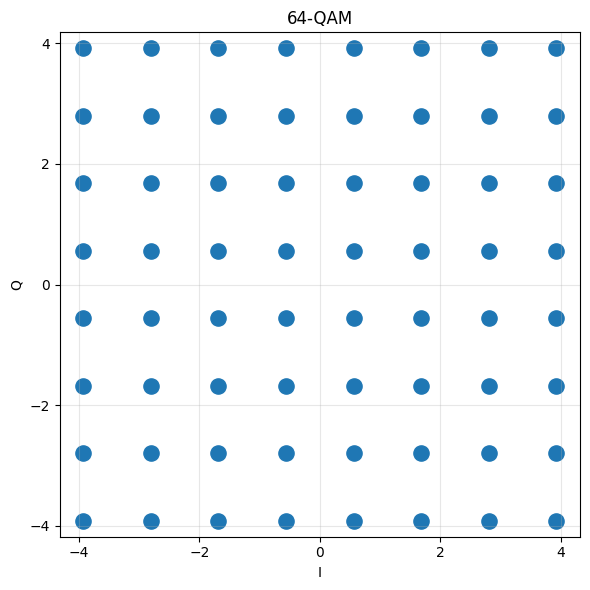

<n> = 10.000000000000002
Saved: C:\Users\barro\OneDrive\Ambiente de Trabalho\Projeto_3ºano\txt\points_random.txt


In [9]:
qam = 64
N = 1_000_000

# ⟨n⟩
n_target = 10

sigma = 15

sqrt_qam = int(np.sqrt(qam))
n_levels = sqrt_qam

# base levels: [-3.5, -2.5, ..., 3.5]
levels_base = np.arange(n_levels) - (n_levels - 1) / 2
I_base, Q_base = np.meshgrid(levels_base, levels_base)
values_base = (I_base + 1j * Q_base).flatten()
r_base = np.abs(values_base)  # |r| = sqrt(I^2 + Q^2)

# MB
probs = np.exp(-r_base**2 / sigma)
probs = probs / probs.sum()

# scale to hit target ⟨n⟩
n_base = np.sum(probs * np.abs(values_base) ** 2)
scale_factor = np.sqrt(n_target / n_base)
levels = levels_base * scale_factor
values = values_base * scale_factor

# plot 2D constellation
plt.figure(figsize=(6, 6))
plt.scatter(np.real(values), np.imag(values), color='C0', s=120)
plt.grid(True, alpha=0.3)
plt.title(f'{qam}-QAM')
plt.xlabel('I')
plt.ylabel('Q')
plt.xticks(np.arange(-14, 15, 2))
plt.yticks(np.arange(-14, 15, 2))
plt.axis('equal')
plt.tight_layout()
plt.show()

n_mean = np.sum(probs * np.abs(values) ** 2)
print('<n> =', n_mean)


idx = np.random.choice(qam, size=N, p=probs)
points = values[idx]

# save sampled points
points_array_np = np.column_stack((np.real(points), np.imag(points)))
np.savetxt(os.path.join(BASE_DIR, "points_random.txt"), points_array_np, fmt="%.6e")
print("Saved:", os.path.join(BASE_DIR, "points_random.txt"))


## 2) 3D histogram of symbol counts

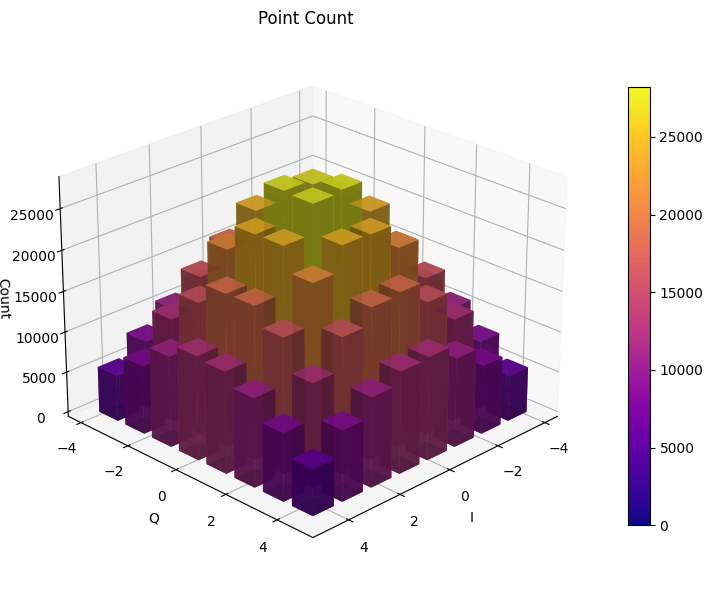

In [3]:
def find_nearest_level(val, levels):
    return np.argmin(np.abs(levels - val))

# 3D histogram
hist_counts = np.zeros((sqrt_qam, sqrt_qam))

for s in points:
    i_val, q_val = np.real(s), np.imag(s)
    i_idx = find_nearest_level(i_val, levels)
    q_idx = find_nearest_level(q_val, levels)
    hist_counts[q_idx, i_idx] += 1

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
X, Y = np.meshgrid(levels, levels)
norm_count = Normalize(0, np.max(hist_counts))

ax.bar3d(
    X.ravel(), Y.ravel(), np.zeros(64),
    0.8, 0.8, hist_counts.ravel(),
    color=plt.cm.plasma(norm_count(hist_counts.ravel())),
    alpha=0.8, edgecolor='none', shade=True
)

ax.set_xlabel('I')
ax.set_ylabel('Q')
ax.set_zlabel('Count')
ax.set_title('Point Count')
ax.view_init(elev=25, azim=45)
fig.colorbar(plt.cm.ScalarMappable(norm=norm_count, cmap=plt.cm.plasma), ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()


## 3) RRC

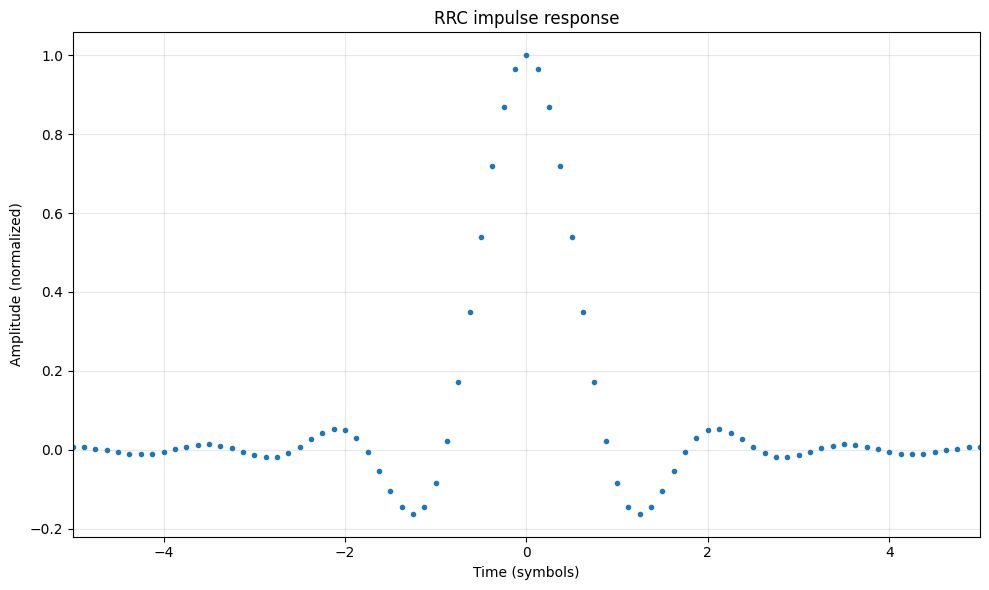

8000000 samples
Saved: C:\Users\barro\OneDrive\Ambiente de Trabalho\Projeto_3ºano\txt\signal_bb.txt


In [4]:
# samples per symbol
ups = 8

# roll-off
alpha = 0.4

# frequency
fc = 153.6e6  # Hz

# upsample
symbols_upsampled = np.zeros(N * ups, dtype=complex)
symbols_upsampled[::ups] = points

def rrcos(Ntaps, alpha, ups):
    T = ups
    t = np.arange(Ntaps) - (Ntaps - 1) / 2
    h = np.zeros_like(t, dtype=float)

    for i, ti in enumerate(t):
        if ti == 0:
            h[i] = 1 + alpha * (4 / np.pi - 1)

        elif np.isclose(abs(ti), T / (4 * alpha)):
            h[i] = (alpha / np.sqrt(2)) * (
                (1 + 2 / np.pi) * np.sin(np.pi / (4 * alpha)) +
                (1 - 2 / np.pi) * np.cos(np.pi / (4 * alpha))
            )

        else:
            num = (
                np.sin(np.pi * ti * (1 - alpha) / T) +
                4 * alpha * ti / T * np.cos(np.pi * ti * (1 + alpha) / T)
            )
            den = (np.pi * ti / T * (1 - (4 * alpha * ti / T) ** 2))
            h[i] = num / den

    # normalize to unit energy
    h /= np.sqrt(np.sum(h**2))
    return h

# filter taps
Ntaps = 10 * ups + 1
rrc = rrcos(Ntaps, alpha, ups)

# plot impulse response
rrc_plot = rrc / np.max(np.abs(rrc))
t_rrc = (np.arange(Ntaps) - (Ntaps - 1) / 2) / ups

plt.figure(figsize=(10, 6))
plt.plot(t_rrc, rrc_plot, '.')
plt.grid(True, alpha=0.3)
plt.xlabel('Time (symbols)')
plt.ylabel('Amplitude (normalized)')
plt.title('RRC impulse response')
plt.xlim(-5, 5)
plt.tight_layout()
plt.show()

# baseband
signal_bb = np.convolve(symbols_upsampled, rrc, mode='same')
print(f'{len(signal_bb)} samples')

signal_bb_array = np.column_stack((np.real(signal_bb), np.imag(signal_bb)))
np.savetxt(os.path.join(BASE_DIR, "signal_bb.txt"), signal_bb_array, fmt="%.6e")
print("Saved:", os.path.join(BASE_DIR, "signal_bb.txt"))


## 4) Scatter plot

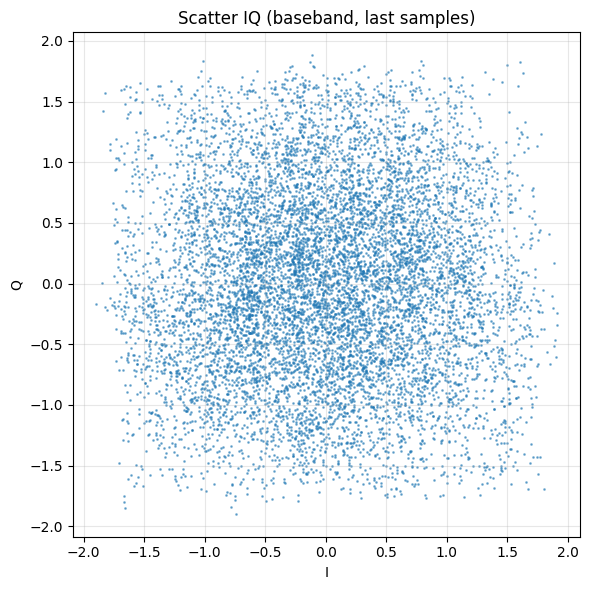

In [5]:
sub_end = -10000  # last points
plt.figure(figsize=(6, 6))
plt.scatter(signal_bb[sub_end:].real, signal_bb[sub_end:].imag, s=1, alpha=0.5, color='C0')
plt.title('Scatter IQ (baseband, last samples)')
plt.xlabel('I')
plt.ylabel('Q')
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 5) Upconversion to RF and FFT

In [6]:
# sampling rate (2x)
fs = 307.2e6  # Hz

t = np.arange(len(signal_bb)) / fs
p = np.exp(1j * 2 * np.pi * fc * t)

# upconverted RF
signal_rf = signal_bb * p

signal_rf_array = np.column_stack((np.real(signal_rf), np.imag(signal_rf)))
np.savetxt(os.path.join(BASE_DIR, "signal_rf_153p6MHz.txt"), signal_rf_array, fmt="%.6e")
print("Saved:", os.path.join(BASE_DIR, "signal_rf_153p6MHz.txt"))

def compute_fft(signal, fs):
    N_fft = len(signal)
    fft_sig = np.fft.fftshift(np.fft.fft(signal))
    f = np.fft.fftshift(np.fft.fftfreq(N_fft, d=1/fs))
    return f, fft_sig

# FFT baseband
f_bb, fft_bb = compute_fft(signal_bb, fs)
fft_bb_array = np.column_stack((f_bb, np.real(fft_bb), np.imag(fft_bb)))
np.savetxt(os.path.join(BASE_DIR, "fft_signal_bb.txt"), fft_bb_array, fmt="%.6e")
print("Saved:", os.path.join(BASE_DIR, "fft_signal_bb.txt"))

# FFT RF
f_rf, fft_rf = compute_fft(signal_rf, fs)
fft_rf_array = np.column_stack((f_rf, np.real(fft_rf), np.imag(fft_rf)))
np.savetxt(os.path.join(BASE_DIR, "fft_signal_rf_153p6MHz.txt"), fft_rf_array, fmt="%.6e")
print("Saved:", os.path.join(BASE_DIR, "fft_signal_rf_153p6MHz.txt"))


Saved: C:\Users\barro\OneDrive\Ambiente de Trabalho\Projeto_3ºano\txt\signal_rf_153p6MHz.txt
Saved: C:\Users\barro\OneDrive\Ambiente de Trabalho\Projeto_3ºano\txt\fft_signal_bb.txt
Saved: C:\Users\barro\OneDrive\Ambiente de Trabalho\Projeto_3ºano\txt\fft_signal_rf_153p6MHz.txt


## 6) plots

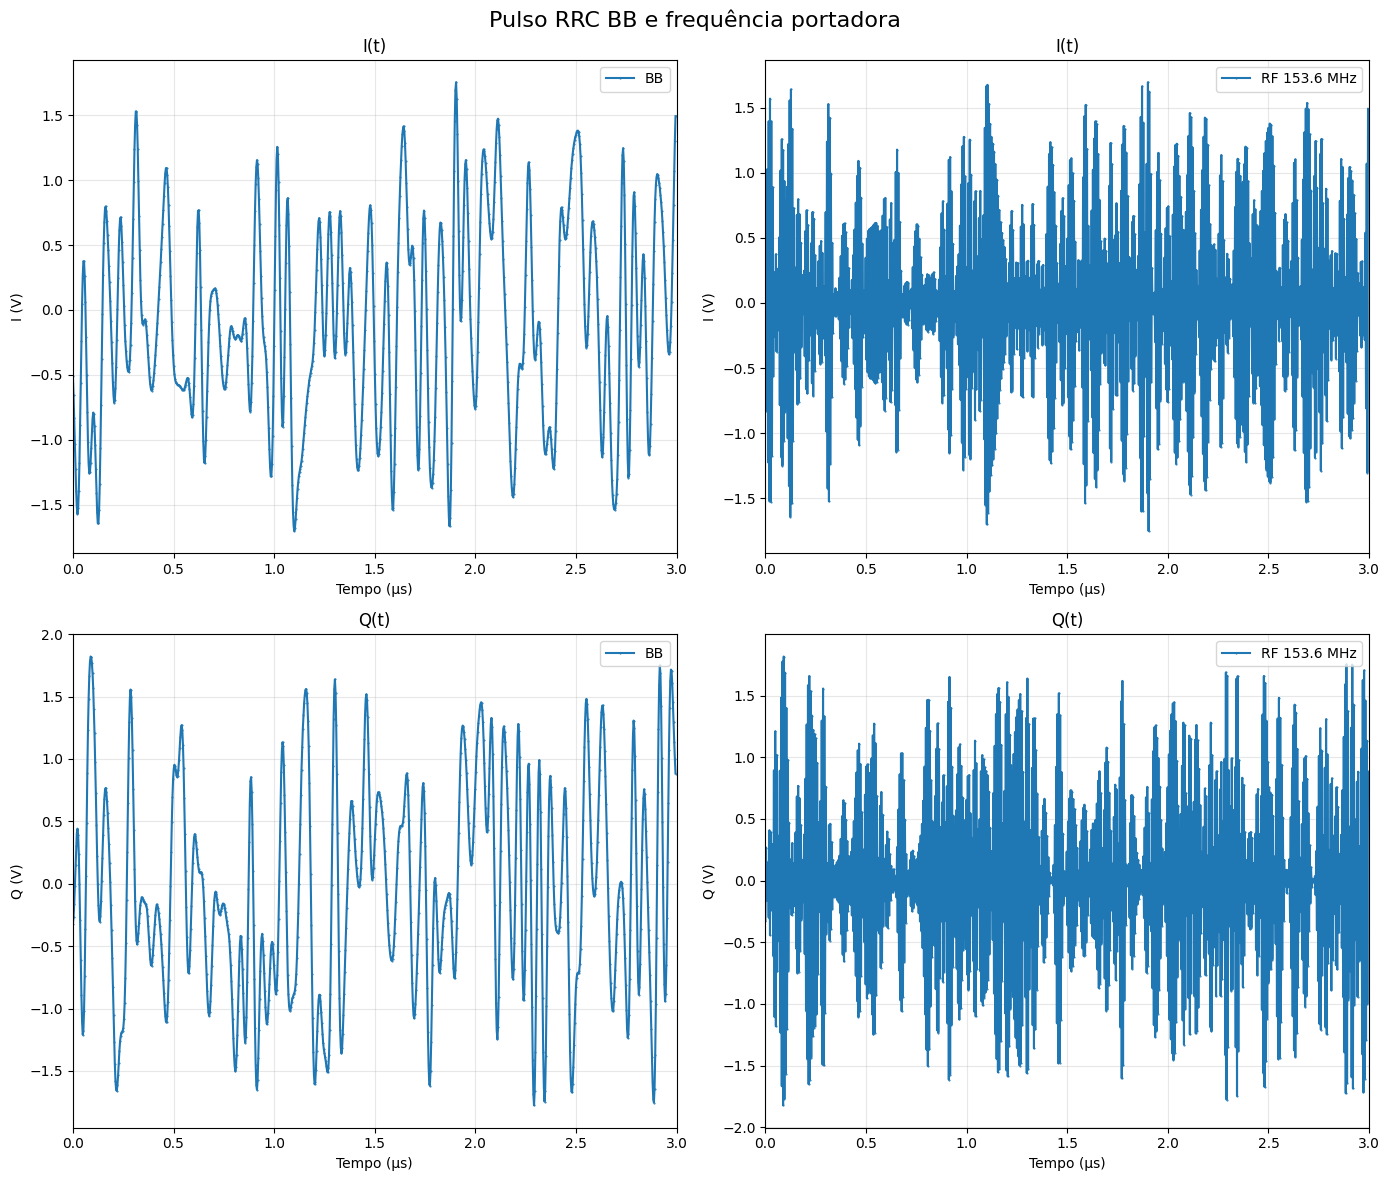

In [7]:
zoom_us = 3
idx_zoom = int(zoom_us * fs / 1e6)

fig, axs = plt.subplots(2, 2, figsize=(14, 12))
for i, comp in enumerate([np.real, np.imag]):
    for j, sig in enumerate([signal_bb, signal_rf]):
        axs[i, j].plot(
            t[:idx_zoom] * 1e6,
            comp(sig[:idx_zoom]),
            '.-',
            ms=1,
            label=f"{'BB' if j==0 else 'RF 153.6 MHz'}"
        )
        axs[i, j].set_title('I(t)' if i == 0 else 'Q(t)')
        axs[i, j].set_xlabel('Tempo (μs)')
        axs[i, j].set_ylabel('I (V)' if i == 0 else 'Q (V)')
        axs[i, j].set_xlim(0, zoom_us)
        axs[i, j].grid(True, alpha=0.3)
        axs[i, j].legend(loc='upper right')

plt.suptitle('Pulso RRC BB e frequência portadora', fontsize=16)
plt.tight_layout()
plt.show()


## 7) PSD

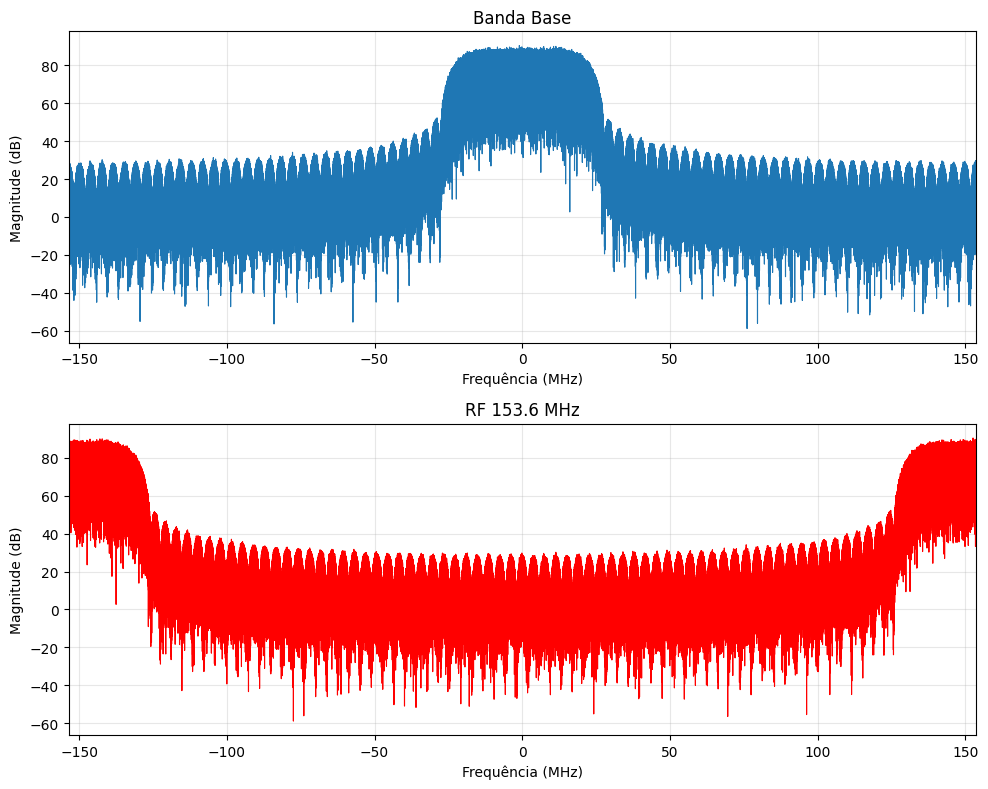

In [8]:
def plot_spectrum(ax, signal, fs, title, color='C0'):
    N = len(signal)
    fft_sig = np.fft.fftshift(np.fft.fft(signal))
    f = np.fft.fftshift(np.fft.fftfreq(N, d=1/fs))
    psd_db = 10 * np.log10(np.abs(fft_sig) ** 2 + 1e-15)

    ax.plot(f / 1e6, psd_db, color=color, linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel('Frequência (MHz)')
    ax.set_ylabel('Magnitude (dB)')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-fs / 2 / 1e6, fs / 2 / 1e6)

fig, axs = plt.subplots(2, 1, figsize=(10, 8))
plot_spectrum(axs[0], signal_bb, fs, 'Banda Base')
plot_spectrum(axs[1], signal_rf, fs, 'RF 153.6 MHz', color='red')

plt.tight_layout()
plt.show()
